In [1]:
import os
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn.init as init
from google.colab.patches import cv2_imshow
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"
print(f"Using {device} device")

Using cpu device


In [3]:
#make_moons
input_size = 2
output_size = 2

X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

# numpy → tensor
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# dataloader
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)

In [4]:
def init_weights(m): #가중치 초기화 함수
    if isinstance(m, nn.Linear):
        # 표준편차(std)=0.01인 정규분포로 가중치 초기화
        init.normal_(m.weight, std=0.1)

In [88]:
class DeepLearning(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.Sigmoid(),
            nn.Linear(16, 16),
            nn.Sigmoid(),
            nn.Linear(16, output_size),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [89]:
model = DeepLearning().to(device) #모델 생성
model.apply(init_weights)

model_before = DeepLearning().to(device)
model_before.load_state_dict(model.state_dict()) #학습전 네트워크 상태 저장용

print(model)
print(model_before)

DeepLearning(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)
DeepLearning(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [98]:
learning_rate = 1e-3
batch_size = 64
epochs = 500

In [99]:
X = torch.rand(1, 1, 2, device=device)
logits = model(X)
init_logits = model(X)

In [100]:
def train(data, model, loss_f, opt):
  size = len(data.dataset)
  model.train()

  for batch, (X, y) in enumerate(data):
    X = X.to(device)
    y = y.to(device)

    pred = model(X)

    #여기는 MSE쓸때만----------------
    #pred = torch.softmax(pred, dim=1) #MSE는 소프트맥스 적용

    #target = F.one_hot(y, num_classes=10).float() #목표 타겟도 10가지의 enum 정수형을 0과 1의 이진 데이터로 변환
    #loss = loss_f(pred, target) #예측이 맞는지 확인
    #---------------------------------------
    #여기는 CrossEntropy쓸때만----------
    loss = loss_f(pred, y)
    #----------------------------------

    opt.zero_grad()
    loss.backward()
    opt.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

  return loss

In [101]:
def test(data, model, loss_f):
  model.eval()
  size = len(data.dataset)
  num_batches = len(data)
  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in data:
      X = X.to(device)
      y = y.to(device)

      pred = model(X)
       #여기는 MSE쓸때만----------------
      #pred = torch.softmax(pred, dim=1) #MSE는 소프트맥스 적용

      #target = F.one_hot(y, num_classes=10).float() #목표 타겟도 10가지의 enum 정수형을 0과 1의 이진 데이터로 변환
      #test_loss += loss_f(pred, target).item() #예측이 맞는지 확인
      #---------------------------------------
      #여기는 CrossEntropy쓸때만----------
      test_loss += loss_f(pred, y).item()
      #----------------------------------
      correct += (pred.argmax(1) == y).type(torch.float).sum().item() #

  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
  return test_loss, correct

In [102]:
loss_fn = nn.CrossEntropyLoss() #손실함수 설정
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #최적화기법 설정

train_loss_list = []
test_loss_list = []
test_accr_list = []

model_middle = DeepLearning().to(device)

for t in range(epochs): #반복
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss_list.append(train(train_dataloader, model, loss_fn, optimizer)) #학습 loss기록
    test_loss, test_accr = test(test_dataloader, model, loss_fn)
    test_loss_list.append(test_loss) #평가 loss기록
    test_accr_list.append(test_accr) #평가 accuracy 기록
    if t == epochs // 2:
      model_middle.load_state_dict(model.state_dict()) #중간 모델 저장
print("Done!")
train_loss_list = [x.item() for x in train_loss_list]

Epoch 1
-------------------------------
loss: 0.693379  [   64/  800]
Test Error: 
 Accuracy: 56.0%, Avg loss: 0.693200 

Epoch 2
-------------------------------
loss: 0.693144  [   64/  800]
Test Error: 
 Accuracy: 46.0%, Avg loss: 0.693280 

Epoch 3
-------------------------------
loss: 0.693221  [   64/  800]
Test Error: 
 Accuracy: 42.0%, Avg loss: 0.693118 

Epoch 4
-------------------------------
loss: 0.693130  [   64/  800]
Test Error: 
 Accuracy: 42.0%, Avg loss: 0.693148 

Epoch 5
-------------------------------
loss: 0.693197  [   64/  800]
Test Error: 
 Accuracy: 41.5%, Avg loss: 0.693091 

Epoch 6
-------------------------------
loss: 0.693113  [   64/  800]
Test Error: 
 Accuracy: 42.0%, Avg loss: 0.693237 

Epoch 7
-------------------------------
loss: 0.693361  [   64/  800]
Test Error: 
 Accuracy: 42.0%, Avg loss: 0.693356 

Epoch 8
-------------------------------
loss: 0.693317  [   64/  800]
Test Error: 
 Accuracy: 42.0%, Avg loss: 0.693118 

Epoch 9
----------------

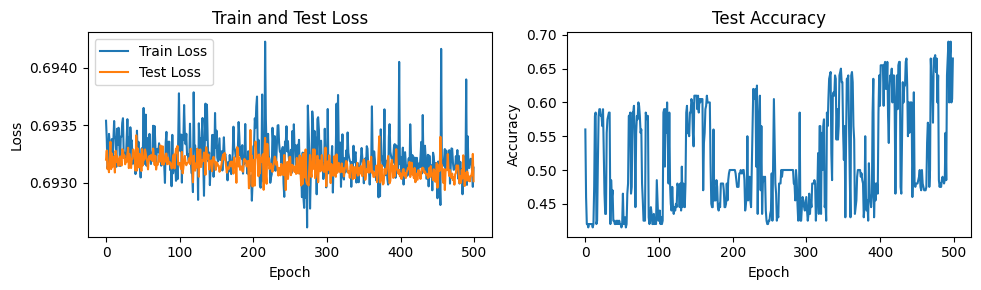

학습 로스 최소값: 0.69261
학습 로스 최소값 에포크:  274
테스트 로스 최소값: 0.69294
테스트 로스 최소값 에포크:  245
테스트 accuracy 최대: 0.69000
테스트 accuracy 최대 에포크:  494


In [103]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list)
plt.plot(test_loss_list)
plt.legend(['Train Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Test Loss')

plt.subplot(1, 2, 2)
plt.plot(test_accr_list)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')

plt.tight_layout()
plt.show()

#각 로스, accuracy 최적값 구하기
min_train_loss = min(train_loss_list)
min_train_epo = train_loss_list.index(min_train_loss) + 1
min_test_loss = min(test_loss_list)
min_test_epo = test_loss_list.index(min_test_loss) + 1
min_test_acc = max(test_accr_list)
min_test_acc_epo = test_accr_list.index(min_test_acc) + 1

print(f"학습 로스 최소값: {min_train_loss:.5f}")
print("학습 로스 최소값 에포크: ", min_train_epo)
print(f"테스트 로스 최소값: {min_test_loss:.5f}")
print("테스트 로스 최소값 에포크: ", min_test_epo)
print(f"테스트 accuracy 최대: {min_test_acc:.5f}")
print("테스트 accuracy 최대 에포크: ", min_test_acc_epo)

<Figure size 1000x400 with 0 Axes>

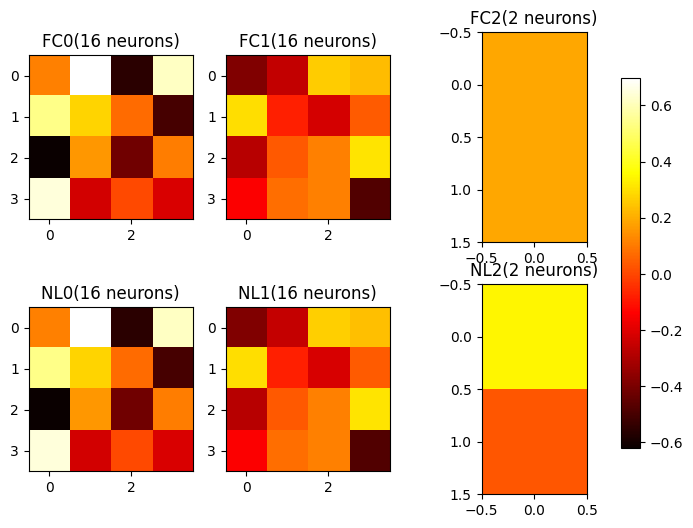

In [104]:
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

def getshape(arr): #가장 정사각형에 가까운 형태를 구하는 코드
  lth = len(arr)
  alterlth = 1
  while lth > alterlth and lth % 2 == 0: #배치 수를 2의 배수로 설정했으니 행을 2로 나누고 2열 2로 곱하면서 행과 열의 크기가 교차하는 순간까지 반복
    lth //= 2
    alterlth *= 2
  return lth, alterlth
hook = []
laylen = len(model.linear_relu_stack) // 2 + 1 #모델 크기 구하기

X = torch.rand(1, 1, 2, device=device)

for i in range(laylen):
  hook.append(model.linear_relu_stack[i * 2].register_forward_hook(get_activation("fc" + str(i))))
  hook.append(model_before.linear_relu_stack[i * 2].register_forward_hook(get_activation("nl" + str(i))))

with torch.no_grad(): #입력값을 넣어서 모델 활성화 하기
    logits = model(X)
    logits2 = model_before(X)

feat = []
for i in range(laylen): #0, 짝수 feat는 full-connected, 홀수 feat는 배우지 않은 초기 노드
  feat.append(activation['fc' + str(i)][0].cpu().numpy())
  feat.append(activation['nl' + str(i)][0].cpu().numpy())

plt.figure(figsize=(10,4))

fig, ax = plt.subplots(2, laylen, figsize=(3*laylen, 6))

all_vals = np.concatenate([f.flatten() for f in feat])
vmin = all_vals.min()
vmax = all_vals.max()

ims = []

for i in range(laylen): #plt에 출력
  lth, alterlth = getshape(feat[i * 2])
  ims.append(ax[0, i].imshow(feat[i * 2].reshape(alterlth,lth), cmap='hot', vmin=vmin, vmax=vmax))
  ax[0, i].set_title("FC" + str(i) + "(" + str(feat[i * 2].shape[0]) + " neurons)")

  lth, alterlth = getshape(feat[i * 2 + 1])
  ims.append(ax[1,i].imshow(feat[i * 2 + 1].reshape(alterlth,lth), cmap='hot', vmin=vmin, vmax=vmax))
  ax[1,i].set_title("NL" + str(i) + "(" + str(feat[i * 2 + 1].shape[0]) + " neurons)")
fig.colorbar(ims[-1], ax=ax, location='right', shrink=0.8)
plt.show()

for i in hook:
  i.remove()